# Classifing Cat sounds

In [1]:
from audio_features_extracture import extract_features_pydub

import os
import pandas as pd
from tqdm.notebook import tqdm

In [2]:
folder_path = "data/audio_cat-classification/NAYA_DATA_AUG1X"
data = []  

# Iterate over all subfolders
for folder_name in os.listdir(folder_path):
    folder_full_path = os.path.join(folder_path, folder_name)
    if os.path.isdir(folder_full_path):  # only folders
        # Iterate over all .mp3 files in this folder
        for file_name in os.listdir(folder_full_path):
            if file_name.lower().endswith(".mp3"):
                file_full_path = os.path.join(folder_full_path, file_name)
                data.append({
                    "file": file_full_path,
                    "label": folder_name
                })


In [3]:
df = pd.DataFrame(data)
df.sample(5)

,file,label
2111,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Mating
1232,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Happy
4217,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Fighting
5247,data/audio_cat-classification/NAYA_DATA_AUG1X/...,MotherCall
5112,data/audio_cat-classification/NAYA_DATA_AUG1X/...,MotherCall


In [4]:
clean_df = df[~df['file'].str.contains('_aug', case=True, na=False)]

In [5]:
# Reset the index so it's clean for your PyTorch Dataset
clean_df = clean_df.reset_index(drop=True)

# Check the new size of your dataset
print(f"Original size: {len(df)}")
print(f"Cleaned size (no aug): {len(clean_df)}")

Original size: 5922
Cleaned size (no aug): 2961


# Training RF baseline

In [18]:
tqdm.pandas(desc="Вилучення MFCC-фіч")

clean_df['features'] = clean_df['file'].apply(
    lambda x: extract_features_pydub(x)
)

⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA (ImportError): data/audio_cat-classification/NAYA_DATA_AUG1X/Paining/car_extcoll0163.mp3. Numba needs NumPy 2.2 or less. Got NumPy 2.4.
⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA (ImportError): data/audio_cat-classification/NAYA_DATA_AUG1X/Paining/cat_flickr0192.mp3. Numba needs NumPy 2.2 or less. Got NumPy 2.4.
⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA (ImportError): data/audio_cat-classification/NAYA_DATA_AUG1X/Paining/car_extcoll0188.mp3. Numba needs NumPy 2.2 or less. Got NumPy 2.4.
⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA (ImportError): data/audio_cat-classification/NAYA_DATA_AUG1X/Paining/Online_Cat0519Hpy.mp3. Numba needs NumPy 2.2 or less. Got NumPy 2.4.
⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA (ImportError): data/audio_cat-classification/NAYA_DATA_AUG1X/Paining/car_extcoll0349.mp3. Numba needs NumPy 2.2 or less. Got NumPy 2.4.
⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA (ImportError): data/audio_cat-classification/NAYA_DATA_AUG1X/Paining/Cat_YoutubeLLT42371(1).mp3. 

KeyboardInterrupt: 

In [ ]:
clean_df['feat_len'] = clean_df['features'].apply(len)
print(df['feat_len'].value_counts())

feat_len
63    5922
Name: count, dtype: int64


In [85]:
df.sample(5)

,file,category,features,feat_len,category
1093,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-118.71788787841797, 31.205270767211914, -8.2...",63,cat
3318,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-219.58274841308594, 81.03300476074219, -0.46...",63,cat
1930,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-484.05035400390625, 110.51231384277344, 27.0...",63,cat
5515,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-328.0287170410156, 128.7935333251953, 15.240...",63,cat
2950,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-169.936767578125, 164.80213928222656, -2.218...",63,cat


In [ ]:
import numpy as np

df['features'] = df['features'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
df.to_csv("audio_cat-emotion_dataframe.csv", index=False)

In [71]:
N = df.shape[0]
N = int(N / 5)
N

1184

In [84]:
df["category"] = "cat"
df = df.rename(
    columns={'label': 'category'}
)
df.sample(5)

,file,category,features,feat_len,category
3256,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-296.97186279296875, 78.90190124511719, 29.65...",63,cat
5770,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-225.5347442626953, 153.66409301757812, 41.62...",63,cat
2756,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-190.14093017578125, 78.00679016113281, -7.12...",63,cat
1325,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-356.20770263671875, 8.466156959533691, -49.4...",63,cat
3996,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-519.9287109375, 57.60646057128906, 12.742654...",63,cat


In [87]:
from sklearn.model_selection import train_test_split

df_base, df_additional = train_test_split(
    df, test_size=0.10, random_state=42
)
df_base.shape, df_additional.shape

((5329, 5), (593, 5))

In [88]:
df_additional.to_csv("audio_cat-emotion_dataframe_sample.csv")

## Loading cat-non-cat model and testing

In [18]:
import joblib

# Load from file
preclassifier_path = "models/audio_preclassifier/voting_classifier.pkl"
voting_clf = joblib.load(preclassifier_path)

In [40]:
X_audio = df["features"]

In [49]:
y_pred = voting_clf.predict(X_audio.to_list())

In [57]:
from data.class_names import pre_classifier_class_names

CAT_INDEX = pre_classifier_class_names.index("cat")

In [58]:
sum([int(y == CAT_INDEX) for y in y_pred]) / len(y_pred)

0.3037825059101655

### Preclassifier with additional data

In [106]:
from IPython.display import Audio

random_audio_path = df.sample()['file'].values[0]
Audio(random_audio_path)

In [117]:
new_path = "models/audio_preclassifier/voting_classifier_with-add-data.pkl"

voting_clf = joblib.load(new_path)

X_audio = df_base["features"]
y_pred = voting_clf.predict(X_audio.to_list())

sum([int(y == CAT_INDEX) for y in y_pred]) / len(y_pred)

0.9553387127040721

HOORAAAAY🥳

can we reuse the same model?

In [144]:
df.sample(3)['file'].values[0]

'data/audio_cat-classification/NAYA_DATA_AUG1X/Paining/car_extcoll0187.mp3'

In [154]:
df.sample(3)['file'].values[0].split('/')[-2]

'Happy'

In [155]:
df['label'] = df['file'].apply(lambda x: x.split('/')[-2])

In [156]:
df.sample(3)

,file,category,features,feat_len,category,label
1893,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-467.9687194824219, 81.18753814697266, -6.470...",63,cat,Mating
1827,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-453.545166015625, 96.75761413574219, 38.6898...",63,cat,Mating
3020,data/audio_cat-classification/NAYA_DATA_AUG1X/...,cat,"[-222.57247924804688, 77.36407470703125, -44.1...",63,cat,Angry


In [157]:
# 2. Підготовка масивів NumPy (як раніше)
X = np.array(df['features'].tolist())
y = np.array(df['label'].tolist())

In [158]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [159]:
le.classes_

array(['Angry', 'Defence', 'Fighting', 'Happy', 'HuntingMind', 'Mating',
       'MotherCall', 'Paining', 'Resting', 'Warning'], dtype='<U11')

In [160]:
# 1. Розділення на тренувальний та тестовий набори (20% для фінальної оцінки)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded # Важливо для збереження балансу класів у наборах
)

print(f"Тренувальний набір: {X_train.shape[0]} зразків")
print(f"Тестовий набір: {X_test.shape[0]} зразків")

Тренувальний набір: 4441 зразків
Тестовий набір: 1481 зразків


In [162]:
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [164]:
final_cls = Pipeline([
    ("scaler", StandardScaler()),
    ("voting", VotingClassifier(
        estimators=[
            (
                'lr',
                LogisticRegression(
                    random_state=42,
                    solver="lbfgs"
                )
            ),
            (
                'rf',
                RandomForestClassifier(
                    random_state=42
                )
            ),
            (
                'hgb',
                HistGradientBoostingClassifier(
                    random_state=42
                )
            )
        ],
        voting="soft",
        weights=[1, 1, 1]
    ))
])

final_cls.fit(X_train, y_train)
y_final = final_cls.predict(X_test)

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       150
           1       0.85      0.84      0.85       146
           2       0.70      0.83      0.76       150
           3       0.81      0.70      0.75       149
           4       0.78      0.78      0.78       144
           5       0.79      0.77      0.78       151
           6       0.79      0.83      0.81       148
           7       0.71      0.66      0.68       145
           8       0.91      0.91      0.91       148
           9       0.78      0.76      0.77       150

    accuracy                           0.79      1481
   macro avg       0.79      0.79      0.78      1481
weighted avg       0.79      0.79      0.78      1481



In [166]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print(classification_report(y_test, y_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       150
           1       0.00      0.00      0.00       146
           2       0.00      0.00      0.00       150
           3       0.00      0.00      0.00       149
           4       0.00      0.00      0.00       144
           5       0.10      1.00      0.19       151
           6       0.00      0.00      0.00       148
           7       0.00      0.00      0.00       145
           8       0.00      0.00      0.00       148
           9       0.00      0.00      0.00       150

    accuracy                           0.10      1481
   macro avg       0.01      0.10      0.02      1481
weighted avg       0.01      0.10      0.02      1481



In [167]:
rf_model = RandomForestClassifier(
    random_state=42,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       150
           1       0.78      0.85      0.81       146
           2       0.65      0.81      0.72       150
           3       0.80      0.68      0.74       149
           4       0.77      0.70      0.73       144
           5       0.75      0.77      0.76       151
           6       0.73      0.77      0.75       148
           7       0.72      0.56      0.63       145
           8       0.87      0.91      0.89       148
           9       0.73      0.69      0.71       150

    accuracy                           0.75      1481
   macro avg       0.75      0.75      0.75      1481
weighted avg       0.75      0.75      0.75      1481



# Building a NN? with Transfer Learning?

In [5]:
df = pd.DataFrame(data)
df.shape

(5922, 2)

In [6]:
df.sample(5)

,file,label
3427,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Angry
80,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Paining
5372,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Resting
1266,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Happy
2101,data/audio_cat-classification/NAYA_DATA_AUG1X/...,Mating


In [8]:
df.label.value_counts()

label
Mating         602
Warning        600
Angry          600
Fighting       600
Happy          594
MotherCall     592
Resting        592
Paining        582
Defence        582
HuntingMind    578
Name: count, dtype: int64

## Option A

Option A 

(Balanced & Smart)

Model: PANNs CNN14

1. Input: 64 or 128 mel bins
2. Fine-tune last 2–3 blocks
3. AdamW optimizer
4. Strong augmentation
5. Expected F1: → 85–92% if dataset is good

In [1]:
!pip install torch torchaudio torchvision
!pip install numpy pandas scikit-learn tqdm matplotlib
!pip install librosa
!pip install torchlibrosa


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import os
import torch
import torchaudio
import random
from torch.utils.data import Dataset

In [12]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

Pre-generated augmented samples were excluded to prevent redundancy and potential bias, since dynamic augmentation was applied during training.

Mild augmentations typically:

1. small pitch shift
2. small gain change
3. tiny time stretch
4. light noise

For a CNN14 model, these differences are often negligible in feature space.

So including them:
1. Inflates dataset size artificially
2. Reduces effective diversity
3. Can bias model toward certain samples

But!
Dynamic augmentation:
1. Produces new variation every epoch
2. Prevents memorization
3. Improves robustness
4. Doesn’t cause leakage

In [13]:
from torch.utils.data import DataLoader
from audio_classifier_utils.data_utils import build_file_list

In [14]:
ROOT_DIR = "data/audio_cat-classification/NAYA_DATA_AUG1X"

In [15]:
train_files, val_files, class_to_idx = build_file_list(ROOT_DIR)

In [16]:
class_to_idx

{'Angry': 0,
 'Defence': 1,
 'Fighting': 2,
 'Happy': 3,
 'HuntingMind': 4,
 'Mating': 5,
 'MotherCall': 6,
 'Paining': 7,
 'Resting': 8,
 'Warning': 9}

In [17]:
len(train_files), len(val_files)

(2368, 593)

### Checking Mel Spectograms

In [13]:
mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=1024,
    hop_length=320,
    n_mels=64
)

In [17]:
!pip install torchcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 5.6 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import librosa
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

In [22]:
path = train_files[0][0]
waveform, sr = librosa.load(path, sr=16000)

# Convert to torch tensor
waveform = torch.tensor(waveform).unsqueeze(0)  # add channel dim

mel = mel(waveform)

In [23]:
mel

tensor([[[3.6865e-05, 6.8430e-03, 3.9913e-03,  ..., 1.1736e-04,
          8.3248e-06, 3.5778e-03],
         [1.2228e-05, 1.2430e-02, 1.3409e-02,  ..., 1.8687e-04,
          2.1264e-04, 6.7285e-03],
         [2.9036e-05, 1.2252e-02, 2.1313e-02,  ..., 9.7016e-04,
          5.4860e-03, 1.1374e-02],
         ...,
         [1.9664e-04, 3.0352e-02, 1.5575e-01,  ..., 7.3515e-02,
          4.7499e-02, 9.8366e-02],
         [2.1363e-04, 1.1481e-02, 7.3823e-02,  ..., 2.9066e-02,
          1.4910e-02, 5.6358e-02],
         [8.7336e-05, 5.7743e-03, 2.7586e-02,  ..., 5.6204e-03,
          5.3390e-03, 2.4023e-02]]])

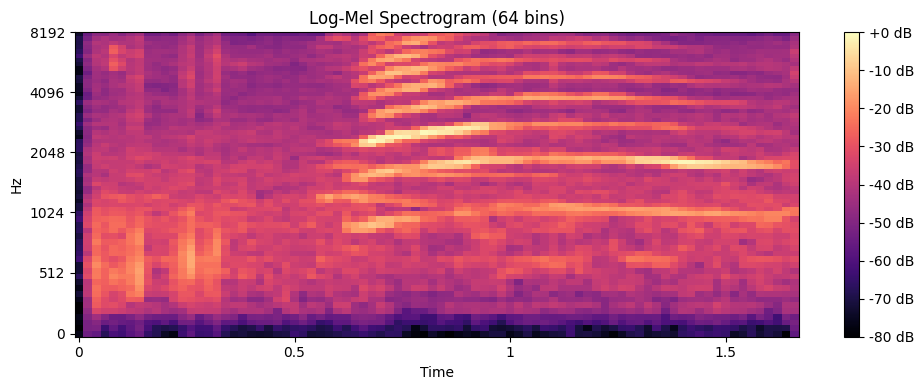

In [25]:
# 1. Remove the batch/channel dimensions and convert to a NumPy array
mel_numpy = mel.squeeze().numpy()

# 2. Convert power/amplitude to decibels (log scale)
mel_db = librosa.power_to_db(mel_numpy, ref=np.max)

# 3. Plot the Spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_db, 
    sr=16000,          # Your target sample rate
    hop_length=320,    # The hop length from your plan
    x_axis='time', 
    y_axis='mel', 
    cmap='magma'       # 'magma' or 'inferno' are standard for spectrograms
)

plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram (64 bins)')
plt.tight_layout()
plt.show()

### Checking Avg. Duration

In [30]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [32]:
def plot_duration_distribution(file_list):
    durations = []
    
    # 1. Extract durations quickly using metadata via librosa
    for path, _ in tqdm(file_list, desc="Scanning audio lengths"):
        # Passing 'path=' tells librosa to just read the file header, not the audio
        duration = librosa.get_duration(path=path)
        durations.append(duration)
        
    durations = np.array(durations)
    
    # 2. Calculate key statistics
    mean_dur = np.mean(durations)
    p90 = np.percentile(durations, 90)
    p95 = np.percentile(durations, 95)
    max_dur = np.max(durations)
    
    print(f"\n--- Duration Stats ---")
    print(f"Mean: {mean_dur:.2f}s")
    print(f"90th Percentile: {p90:.2f}s")
    print(f"95th Percentile: {p95:.2f}s")
    print(f"Max Duration: {max_dur:.2f}s")
    
    # 3. Plot the histogram
    plt.figure(figsize=(10, 5))
    plt.hist(durations, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(p95, color='red', linestyle='dashed', linewidth=2, label=f'95th Percentile ({p95:.2f}s)')
    
    plt.title('Distribution of Cat Emotion Audio Durations')
    plt.xlabel('Duration (Seconds)')
    plt.ylabel('Number of Audio Files')
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

Scanning audio lengths: 100%|██████████| 2368/2368 [00:00<00:00, 2445.56it/s]



--- Duration Stats ---
Mean: 3.87s
90th Percentile: 6.11s
95th Percentile: 6.81s
Max Duration: 16.82s


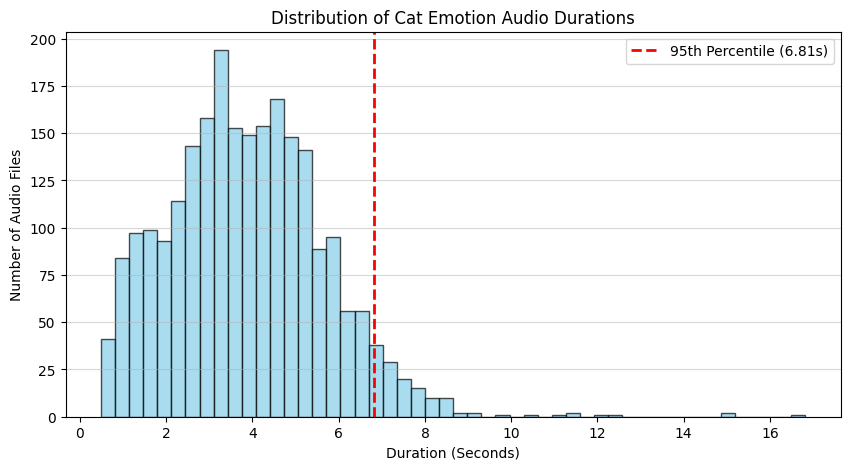

In [33]:
# Run it on your list of (file_path, label) tuples!
plot_duration_distribution(train_files)

### Preparing Dataset

In [26]:
from audio_classifier_utils.dataset import CatEmotionDataset
from audio_classifier_utils.audio_config import AudioConfig

In [27]:
audio_config = AudioConfig()
audio_config

AudioConfig(sample_rate=16000, window_size=1024, hop_size=320, mel_bins=64, fmin=50, fmax=8000, checkpoint_path='audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth', num_classes=10, augmentation_prob=0.4, target_length=112000)

In [28]:
train_dataset = CatEmotionDataset(train_files, audio_config, train=True)
val_dataset = CatEmotionDataset(val_files, audio_config, train=False)

In [29]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [30]:
train_dataset[0]

(tensor([ 0.0021,  0.0015,  0.0030,  ..., -0.0023, -0.0031, -0.0041]), 7)

### Training Model

In [31]:
from audio_classifier_utils.audio_config import AudioConfig
from audio_classifier_utils.models.cnn14 import CatEmotionModel

In [32]:
CatEmotionModel(audio_config).forward(train_dataset[0][0].unsqueeze(0))

Loading pre-trained weights from audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth...
Weights loaded successfully!


tensor([[-0.9122, -1.1434, -0.2667,  0.9434, -0.7404,  1.4861,  1.1059,  1.5058,
         -0.7940, -0.4477]], grad_fn=<AddmmBackward0>)

### Training (Finally!)

#### 🧩 STEP 4 — Phase 1 Setup

In [33]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score
from tqdm import tqdm
import copy

In [34]:
cnn14_model = CatEmotionModel(audio_config).to(device)

Loading pre-trained weights from audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth...
Weights loaded successfully!


In [26]:
cnn14_model.freeze_for_phase1()

In [27]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cnn14_model.parameters()), 
    lr=1e-3, 
    weight_decay=1e-4
)

# Cosine Annealing decays the LR smoothly over the epochs
scheduler = CosineAnnealingLR(optimizer, T_max=10) # T_max = Phase 1 epochs

#### 🧩 STEP 5 & 7 — Unified Training & Eval Functions

In [28]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    # Renamed 'mel' to 'waveform' to match reality
    for waveform, label in tqdm(loader, desc="Training"):
        waveform = waveform.to(device)
        label = label.to(device)
        
        optimizer.zero_grad()
        outputs = model(waveform)
        loss = criterion(outputs, label)
        loss.backward()
        
        # Prevent exploding audio gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(loader)

In [35]:
def evaluate(model, loader, criterion):
    model.eval()
    preds, targets = [], []
    total_loss = 0.0  # Keep track of the validation loss
    
    # torch.no_grad() is crucial here! It tells PyTorch NOT to track 
    # gradients, which saves tons of memory and speeds up evaluation.
    with torch.no_grad():
        for waveform, label in loader:
            waveform = waveform.to(device)
            # Make sure label is on the GPU too, so criterion can compare them!
            label = label.to(device) 
            
            outputs = model(waveform)
            
            # 1. Calculate the loss for this batch
            loss = criterion(outputs, label)
            total_loss += loss.item()
            
            # 2. Calculate predictions for F1 score
            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            label_cpu = label.cpu().numpy() # Move back to CPU for sklearn
            
            preds.extend(pred)
            targets.extend(label_cpu)

    # Calculate final metrics
    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(targets, preds, average="macro")

    return avg_loss, macro_f1

In [36]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Loss curves (Train vs Validation)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot 2: Macro F1 Score
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_f1'], label='Validation Macro F1', color='green', marker='s')
    plt.title('Validation Macro F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

#### 🧩 The Actual Phase 1 Loop

In [37]:
import copy
import matplotlib.pyplot as plt

In [38]:
# 1. Initialize our tracking dictionary
history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': []
}

best_f1 = 0.0
best_model_weights = None

In [39]:
print("Starting Phase 1 Training...")

for epoch in range(10):
    # Train and Evaluate
    train_loss = train_epoch(cnn14_model, train_loader, optimizer, criterion)
    
    # NOTE: You will need to slightly update your `evaluate` function 
    # to also calculate and return the validation loss alongside F1!
    val_loss, val_f1 = evaluate(cnn14_model, val_loader, criterion) 
    
    # Step the scheduler
    scheduler.step() 
    
    # 2. Save the metrics for this epoch
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1:02d}/10 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # 3. Save the best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_weights = copy.deepcopy(cnn14_model.state_dict())
        print(f"   -> 🌟 New best model saved! (F1: {best_f1:.4f})")

# Load the best weights back into the model before Phase 2 or inference
cnn14_model.load_state_dict(best_model_weights)

Starting Phase 1 Training...


Training:   7%|▋         | 5/74 [00:02<00:28,  2.46it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:25<00:00,  2.95it/s]


Epoch 01/10 | Train Loss: 2.1443 | Val Loss: 1.7157 | Val F1: 0.4576
   -> 🌟 New best model saved! (F1: 0.4576)


Training:  85%|████████▌ | 63/74 [00:20<00:03,  3.15it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:24<00:00,  3.04it/s]


Epoch 02/10 | Train Loss: 2.0588 | Val Loss: 1.8236 | Val F1: 0.4428


...

Training:  43%|████▎     | 32/74 [00:10<00:13,  3.17it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:24<00:00,  3.02it/s]


Epoch 09/10 | Train Loss: 1.9499 | Val Loss: 1.6112 | Val F1: 0.6398


Training:  78%|███████▊  | 58/74 [00:19<00:05,  3.13it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:24<00:00,  2.98it/s]


Epoch 10/10 | Train Loss: 1.9540 | Val Loss: 1.6638 | Val F1: 0.6521
   -> 🌟 New best model saved! (F1: 0.6521)


<All keys matched successfully>

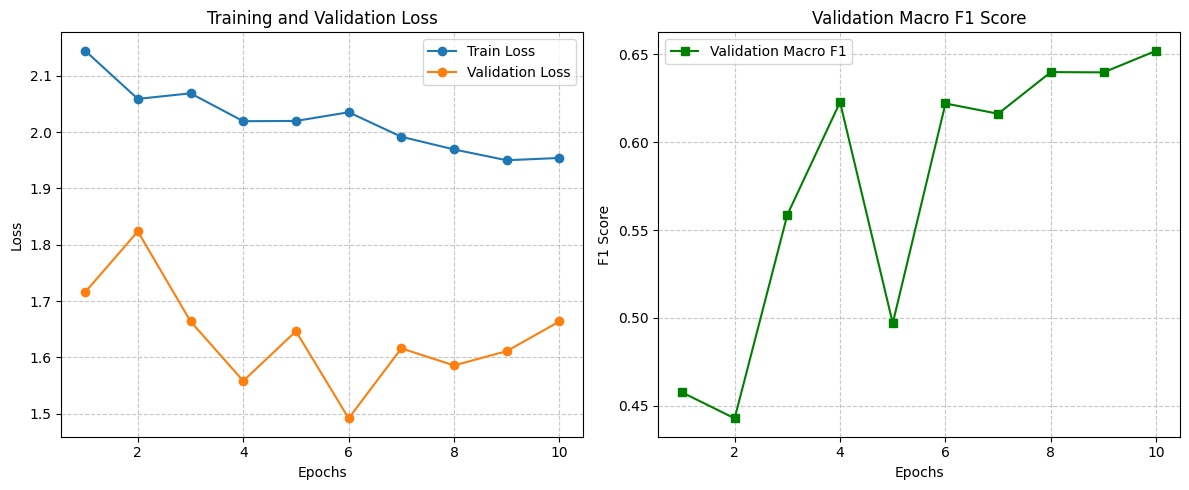

In [40]:
plot_training_history(history)

#### With Early Stopping

In [41]:
# 1. Initialize our tracking dictionary
history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': []
}

# Setup Early Stopping & Checkpoint Directory
max_epochs = 100
patience = 10  # How many epochs to wait before giving up
epochs_no_improve = 0

best_f1 = 0.0
best_model_weights = None

In [43]:
os.makedirs("checkpoints", exist_ok=True) # Creates a folder for your save

In [45]:
print("Starting Phase 1 Training...")

for epoch in range(max_epochs):
    # Train and Evaluate
    train_loss = train_epoch(cnn14_model, train_loader, optimizer, criterion)
    val_loss, val_f1 = evaluate(cnn14_model, val_loader, criterion) 
    scheduler.step() 
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1:02d}/{max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # 2. Package the Checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': cnn14_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_f1': val_f1
    }

    # 3. Save the current epoch's checkpoint
    current_ckpt_path = f"checkpoints/PANN_cnn14_checkpoint_{epoch}.pth"
    torch.save(checkpoint, current_ckpt_path)
    
    # --- THE SAFETY VALVE: Delete the checkpoint from 3 epochs ago ---
    old_ckpt_path = f"checkpoints/PANN_cnn14_checkpoint_{epoch-3}.pth"
    if os.path.exists(old_ckpt_path):
        os.remove(old_ckpt_path)
    # -----------------------------------------------------------------
    
    # 4. Save the BEST checkpoint & check Early Stopping
    if val_f1 > best_f1:
        best_f1 = val_f1
        epochs_no_improve = 0 # Reset patience counter
        
        # Overwrite the best model file (this one is NEVER deleted)
        torch.save(checkpoint, "checkpoints/best_model.pth")
        print(f"   -> 🌟 New best model saved to disk! (F1: {best_f1:.4f})")
    else:
        epochs_no_improve += 1
        print(f"   -> No improvement for {epochs_no_improve} epochs.")
        
    # 5. Trigger Early Stopping
    if epochs_no_improve >= patience:
        print(f"\n🛑 Early stopping triggered! Model hasn't improved in {patience} epochs.")
        print(f"The best Validation F1 was: {best_f1:.4f}")
        break

Starting Phase 1 Training...


Training:  31%|███       | 23/74 [00:09<00:15,  3.19it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:26<00:00,  2.84it/s]


Epoch 01/100 | Train Loss: 1.9703 | Val Loss: 1.7702 | Val F1: 0.5786
   -> 🌟 New best model saved to disk! (F1: 0.5786)


Training:  35%|███▌      | 26/74 [00:08<00:15,  3.19it/s]Warning: Xing stream size off by more than 1%, fuzzy seeking may be even more fuzzy than by design!
Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:23<00:00,  3.11it/s]


Epoch 02/100 | Train Loss: 1.9524 | Val Loss: 1.5435 | Val F1: 0.6280
   -> 🌟 New best model saved to disk! (F1: 0.6280)


...

Epoch 13/100 | Train Loss: 2.0296 | Val Loss: 1.4195 | Val F1: 0.6437
   -> No improvement for 8 epochs.


Training:  55%|█████▌    | 41/74 [00:13<00:10,  3.07it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:24<00:00,  3.07it/s]


Epoch 14/100 | Train Loss: 2.0014 | Val Loss: 1.5838 | Val F1: 0.5900
   -> No improvement for 9 epochs.


Training:  80%|███████▉  | 59/74 [00:18<00:04,  3.14it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:23<00:00,  3.13it/s]


Epoch 15/100 | Train Loss: 2.0193 | Val Loss: 1.4034 | Val F1: 0.6375
   -> No improvement for 10 epochs.

🛑 Early stopping triggered! Model hasn't improved in 10 epochs.
The best Validation F1 was: 0.6502


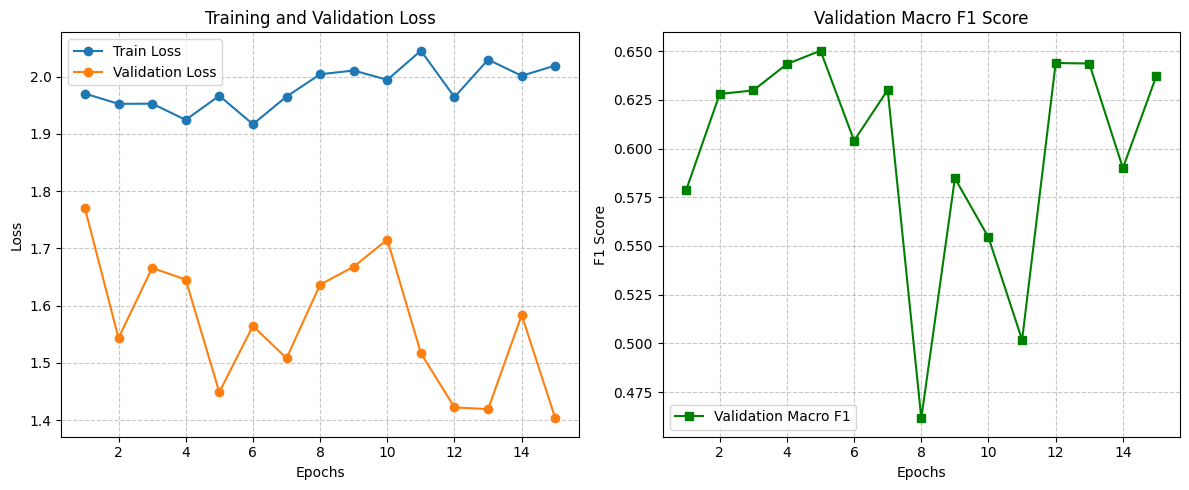

In [46]:
plot_training_history(history)

Before we change any hyperparameters, we need to see exactly what the model is failing at. Is it confusing "hungry" with "attention," or is it failing completely on a specific minority class?

In [36]:
import torch
from sklearn.metrics import classification_report

def get_detailed_report(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms = waveforms.to(device)
            outputs = model(waveforms)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(labels.numpy())
            
    # Print the detailed breakdown per class!
    print(classification_report(all_targets, all_preds, zero_division=0))

# Load your best weights
cnn14_model.load_state_dict(torch.load("checkpoints/best_model.pth")['model_state_dict'])

# Run the report on your validation data
get_detailed_report(cnn14_model, val_loader)

              precision    recall  f1-score   support

           0       0.63      0.37      0.46        60
           1       0.80      0.90      0.85        58
           2       0.70      0.72      0.71        60
           3       0.58      0.70      0.64        60
           4       0.69      0.79      0.74        58
           5       0.65      0.51      0.57        61
           6       0.72      0.81      0.76        59
           7       0.44      0.59      0.50        58
           8       0.80      0.88      0.84        59
           9       0.58      0.35      0.44        60

    accuracy                           0.66       593
   macro avg       0.66      0.66      0.65       593
weighted avg       0.66      0.66      0.65       593



In [38]:
class_to_idx

{'Angry': 0,
 'Defence': 1,
 'Fighting': 2,
 'Happy': 3,
 'HuntingMind': 4,
 'Mating': 5,
 'MotherCall': 6,
 'Paining': 7,
 'Resting': 8,
 'Warning': 9}

The Good, The Bad, and The Confused

1. The Model is Working (The Good)
Look at Class 1 and Class 8.

    Class 1 has an F1 of 0.85.

    Class 8 has an F1 of 0.84.
    Whatever cat emotions these are, they have distinct, clear acoustic signatures, and your CNN14 backbone is identifying them almost perfectly.

2. The Blind Spots (The Bad)
Look at Class 0 and Class 9.

    Class 9 has a Recall of 0.35. This means that when the audio actually is Class 9, the model only notices it 35% of the time. The other 65% of the time, the model is completely blind to it and guesses something else.

3. The Dumping Ground (The Confused)
Look at Class 7.

    It has a Precision of 0.44. This means that when the model predicts Class 7, it is wrong more than half the time! Class 7 has become the model's "dumping ground." When it hears an audio file it doesn't understand (like the ones from Class 0 or 9), it throws its hands up and guesses, "Uh, I don't know, maybe it's Class 7?"

How do we fix this?

Since your data is balanced, the issue is purely in the Training Strategy. We are likely suffering from "Catastrophic Forgetting." If you passed all of CNN14's parameters into the optimizer at once with a standard learning rate, the model aggressively overwrote its incredible pre-trained audio knowledge trying to learn Class 7.

To fix this and push past 0.65, we need to do two things:

    See exactly what it's confusing: We need a Confusion Matrix.

    Two-Stage Fine-Tuning: We need to "freeze" the CNN14 backbone for the first few epochs so only your new 10-class classifier head learns, and then unfreeze it with a microscopic learning rate.

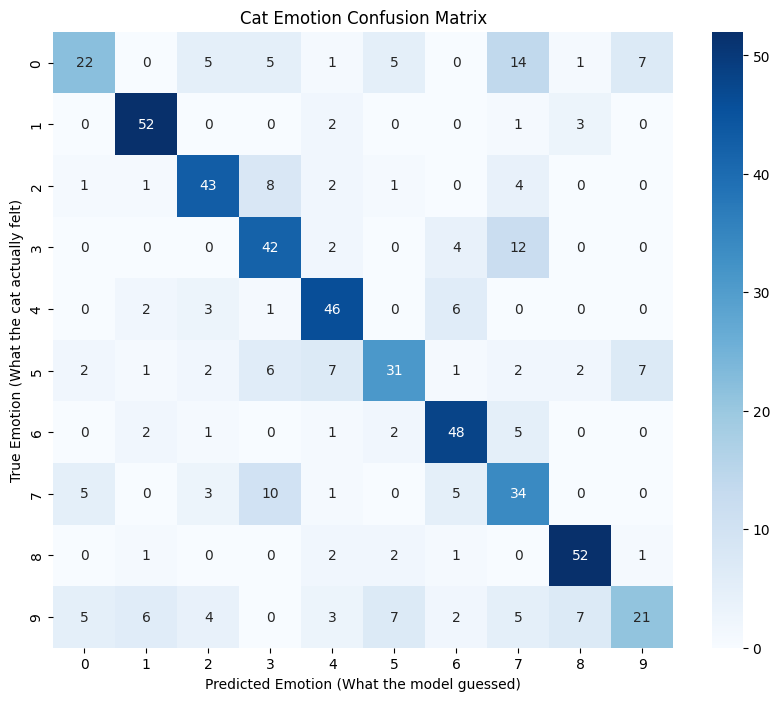

In [39]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms = waveforms.to(device)
            outputs = model(waveforms)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(labels.numpy())
            
    # Generate the matrix
    cm = confusion_matrix(all_targets, all_preds)
    
    # Plot it
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Emotion (What the model guessed)')
    plt.ylabel('True Emotion (What the cat actually felt)')
    plt.title('Cat Emotion Confusion Matrix')
    plt.show()

# Run it!
plot_confusion_matrix(cnn14_model, val_loader)

Biggest mixes are:
1. 0 and 7 - 14, Angry and Paining
2. 3 and 7 - 12, Happy and Paining
3. 3 and 2 - 8, Happy and Fighting
4. 3 and 7 - 10, Happy and Paining
5. 5 and 9, 8 and 9, 5 and 9, 0 and 9 - 7

#### Two Phase Training

In [40]:
import os
import torch
from torch.optim.lr_scheduler import CosineAnnealingLR

In [41]:
# 1. Setup Tracking and Directories
os.makedirs("checkpoints", exist_ok=True)
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
criterion = torch.nn.CrossEntropyLoss()

In [42]:
# ==========================================
# 🚀 PHASE 1: WARM UP THE CLASSIFIER HEAD
# ==========================================
print("🧊 PHASE 1: Freezing backbone, warming up the head...")
phase1_epochs = 10
best_f1 = 0.0

🧊 PHASE 1: Freezing backbone, warming up the head...


In [43]:
cnn14_model = CatEmotionModel(audio_config).to(device)

Loading pre-trained weights from audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth...
Weights loaded successfully!


In [56]:
# Freeze the model using your custom method
cnn14_model.freeze_for_phase1()

In [57]:
# Initialize Optimizer & Scheduler for Phase 1
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cnn14_model.parameters()), 
    lr=1e-3, 
    weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=phase1_epochs)

In [58]:
for epoch in range(phase1_epochs):
    train_loss = train_epoch(cnn14_model, train_loader, optimizer, criterion)
    val_loss, val_f1 = evaluate(cnn14_model, val_loader, criterion) 
    scheduler.step() 
    
    # Track metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    print(f"Phase 1 - Epoch {epoch+1:02d}/{phase1_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # Save best Phase 1 model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(cnn14_model.state_dict(), "checkpoints/best_model_phase1.pth")

Training:  45%|████▍     | 33/74 [00:12<00:13,  3.03it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:25<00:00,  2.88it/s]


Phase 1 - Epoch 01/10 | Train Loss: 2.4626 | Val Loss: 1.9550 | Val F1: 0.4603


Training:  77%|███████▋  | 57/74 [00:18<00:05,  3.09it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:23<00:00,  3.11it/s]


Phase 1 - Epoch 02/10 | Train Loss: 2.1156 | Val Loss: 1.6858 | Val F1: 0.4917


Training:  76%|███████▌  | 56/74 [00:17<00:05,  3.20it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:23<00:00,  3.12it/s]


...

Phase 1 - Epoch 08/10 | Train Loss: 1.9589 | Val Loss: 1.6883 | Val F1: 0.5988


Training:  41%|████      | 30/74 [00:09<00:14,  3.02it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:25<00:00,  2.90it/s]


Phase 1 - Epoch 09/10 | Train Loss: 1.9520 | Val Loss: 1.5332 | Val F1: 0.6360


Training:   4%|▍         | 3/74 [00:01<00:24,  2.92it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:25<00:00,  2.93it/s]


Phase 1 - Epoch 10/10 | Train Loss: 1.9453 | Val Loss: 1.6058 | Val F1: 0.6321


In [44]:
# ==========================================
# 🔥 PHASE 2: UNFREEZE & FINE-TUNE
# ==========================================
print(f"\n🔥 PHASE 2: Unfreezing blocks 5 & 6... (Best Phase 1 F1: {best_f1:.4f})")

# 1. Load the smartest head from Phase 1 before unfreezing
cnn14_model.load_state_dict(torch.load("checkpoints/best_model_phase1.pth", weights_only=True))

# 2. Unfreeze blocks 5, 6, and fc1 using your custom method
cnn14_model.unfreeze_for_phase2()


🔥 PHASE 2: Unfreezing blocks 5 & 6... (Best Phase 1 F1: 0.0000)


In [60]:
# 3. CRITICAL: Rebuild the optimizer with a LOWER learning rate (1e-4)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cnn14_model.parameters()), 
    lr=1e-4,  # <-- 10x smaller than Phase 1!
    weight_decay=1e-4
)

# 4. Rebuild Scheduler & Early Stopping rules
phase2_max_epochs = 50
scheduler = CosineAnnealingLR(optimizer, T_max=phase2_max_epochs)

patience = 10
epochs_no_improve = 0
# We keep the best_f1 from Phase 1 as our benchmark to beat

In [61]:
for epoch in range(phase2_max_epochs):
    train_loss = train_epoch(cnn14_model, train_loader, optimizer, criterion)
    val_loss, val_f1 = evaluate(cnn14_model, val_loader, criterion) 
    scheduler.step() 
    
    # Track metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    print(f"Phase 2 - Epoch {epoch+1:02d}/{phase2_max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # --- ROLLING BUFFER CHECKPOINT SAVING ---
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': cnn14_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_f1': val_f1
    }
    current_ckpt_path = f"checkpoints/PANN_cnn14_ckpt_{epoch}.pth"
    torch.save(checkpoint, current_ckpt_path)
    
    old_ckpt_path = f"checkpoints/PANN_cnn14_ckpt_{epoch-3}.pth"
    if os.path.exists(old_ckpt_path):
        os.remove(old_ckpt_path)
    # ----------------------------------------
    
    # Early Stopping & Best Model checking
    if val_f1 > best_f1:
        best_f1 = val_f1
        epochs_no_improve = 0
        torch.save(checkpoint, "checkpoints/best_model_final.pth")
        print(f"   -> 🌟 New all-time best model saved! (F1: {best_f1:.4f})")
    else:
        epochs_no_improve += 1
        print(f"   -> No improvement for {epochs_no_improve} epochs.")
        
    if epochs_no_improve >= patience:
        print(f"\n🛑 Early stopping triggered! Model hasn't improved in {patience} epochs.")
        break

print(f"\n🎉 Training Complete! Your ultimate F1 Score is: {best_f1:.4f}")

Training:  50%|█████     | 37/74 [00:21<00:18,  2.01it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:40<00:00,  1.82it/s]


Phase 2 - Epoch 01/50 | Train Loss: 1.7899 | Val Loss: 0.9622 | Val F1: 0.7356
   -> 🌟 New all-time best model saved! (F1: 0.7356)


Training:  64%|██████▎   | 47/74 [00:24<00:13,  2.02it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:38<00:00,  1.92it/s]


Phase 2 - Epoch 02/50 | Train Loss: 1.3765 | Val Loss: 0.6911 | Val F1: 0.7904
   -> 🌟 New all-time best model saved! (F1: 0.7904)


Training:   1%|▏         | 1/74 [00:00<00:38,  1.89it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:39<00:00,  1.85it/s]


...

Phase 2 - Epoch 45/50 | Train Loss: 0.3333 | Val Loss: 0.2851 | Val F1: 0.8993
   -> No improvement for 8 epochs.


Training:  32%|███▏      | 24/74 [00:11<00:23,  2.12it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:35<00:00,  2.10it/s]


Phase 2 - Epoch 46/50 | Train Loss: 0.3249 | Val Loss: 0.2854 | Val F1: 0.9008
   -> No improvement for 9 epochs.


Training:  81%|████████  | 60/74 [00:28<00:06,  2.15it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Training: 100%|██████████| 74/74 [00:34<00:00,  2.12it/s]


Phase 2 - Epoch 47/50 | Train Loss: 0.3413 | Val Loss: 0.2861 | Val F1: 0.8996
   -> No improvement for 10 epochs.

🛑 Early stopping triggered! Model hasn't improved in 10 epochs.

🎉 Training Complete! Your ultimate F1 Score is: 0.9078


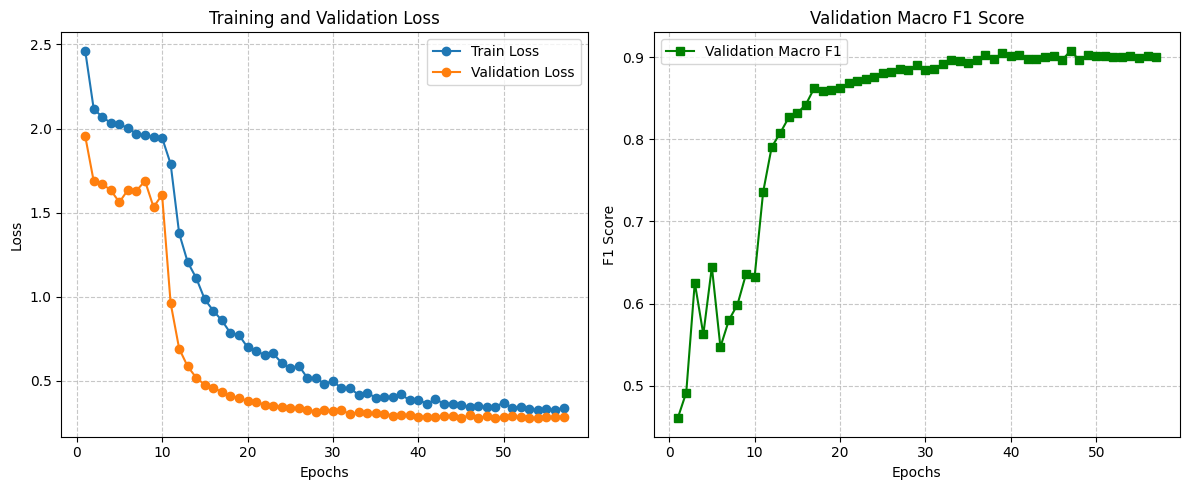

In [62]:
plot_training_history(history)

🎉 Training Complete! Your ultimate F1 Score is: 0.9078

Phase 1: 5 minutes, 6.3 seconds (10 epochs)

Phase 2: 34 minutes, 5.3 seconds (47 epochs, last 10 with no improvement)

In [45]:
# Load your best weights
cnn14_model.load_state_dict(torch.load("checkpoints/best_model_final.pth")['model_state_dict'])

# Run the report on your validation data
get_detailed_report(cnn14_model, val_loader)

              precision    recall  f1-score   support

           0       0.90      0.87      0.88        60
           1       0.98      0.97      0.97        58
           2       0.93      0.93      0.93        60
           3       0.90      0.88      0.89        60
           4       0.95      0.97      0.96        58
           5       0.82      0.97      0.89        61
           6       0.98      0.88      0.93        59
           7       0.76      0.78      0.77        58
           8       1.00      0.98      0.99        59
           9       0.88      0.85      0.86        60

    accuracy                           0.91       593
   macro avg       0.91      0.91      0.91       593
weighted avg       0.91      0.91      0.91       593



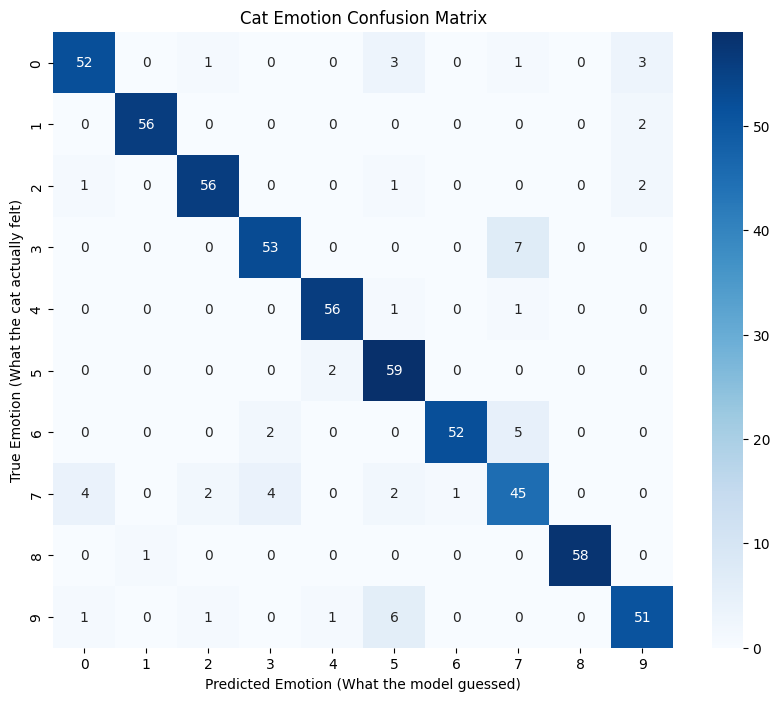

In [46]:
# Run it!
plot_confusion_matrix(cnn14_model, val_loader)

In [47]:
class_to_idx

{'Angry': 0,
 'Defence': 1,
 'Fighting': 2,
 'Happy': 3,
 'HuntingMind': 4,
 'Mating': 5,
 'MotherCall': 6,
 'Paining': 7,
 'Resting': 8,
 'Warning': 9}

## Explainability

### Galaxy Map (t-SNE)

Remember how your model was horribly confused between Class 0, 3, and 7 earlier? We can visually prove that Phase 2 fixed this.

Instead of asking the model for the final 10-class prediction, we ask it to output the 2048-dimensional embedding (the raw features right before the final classifier). We then use an algorithm called t-SNE to squash those 2048 dimensions down to 2 dimensions and plot every single audio file as a dot on a scatter plot.

To build this, we don't want the final 10-class predictions. We want the 2048-dimensional embeddings that come out of the CNN14 backbone just before your custom classifier head.

We will extract these 2048 numbers for every audio file in your validation set, and then use the t-SNE algorithm to mathematically squash those 2048 dimensions down to exactly 2 dimensions (X and Y coordinates) so we can plot them on a 2D graph.

In [18]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [19]:
# 1. Function to extract the deep features (embeddings)
def get_embeddings(model, loader, device='cuda'):
    print("Extracting 2048-D embeddings from the CNN14 backbone...")
    model.eval()
    model.to(device)
    
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms = waveforms.to(device)
            
            # Instead of calling model(waveforms) which gives the final 10 classes,
            # we call the backbone directly to get the deep features!
            output_dict = model.backbone(waveforms)
            embeddings = output_dict['embedding'] # Shape: (Batch, 2048)
            
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())
            
    # Stack all batches into one giant numpy array
    return np.vstack(all_embeddings), np.concatenate(all_labels)

In [20]:
# 2. Function to calculate and plot t-SNE
def plot_tsne_galaxy_map(embeddings, labels, class_names=None):
    print(f"Running t-SNE on {embeddings.shape[0]} audio files. This might take a minute...")
    
    # Initialize t-SNE. 
    # Perplexity is a tuneable parameter usually between 5 and 50. 30 is standard.
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    
    # Squash 2048 dimensions down to 2 dimensions!
    tsne_results = tsne.fit_transform(embeddings)
    
    # Map numeric labels to names if provided
    if class_names:
        plot_labels = [class_names[label] for label in labels]
    else:
        plot_labels = [f"Class {label}" for label in labels]
    
    # Create a beautiful seaborn plot
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1],
        hue=plot_labels,
        palette="tab10", # A great color palette for 10 classes
        legend="full",
        alpha=0.8,
        s=60, # Size of the dots
        edgecolor='k',
        linewidth=0.5
    )
    
    plt.title("t-SNE 'Galaxy Map' of Cat Emotion Audio Features", fontsize=16, pad=20)
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    
    # Clean up the legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Emotions")
    plt.tight_layout()
    plt.show()

In [21]:
class_to_idx

{'Angry': 0,
 'Defence': 1,
 'Fighting': 2,
 'Happy': 3,
 'HuntingMind': 4,
 'Mating': 5,
 'MotherCall': 6,
 'Paining': 7,
 'Resting': 8,
 'Warning': 9}

In [22]:
idx_to_class = {
    0: 'Angry',
    1: 'Defence',
    2: 'Fighting',
    3: 'Happy',
    4: 'HuntingMind',
    5: 'Mating',
    6: 'MotherCall',
    7: 'Paining',
    8: 'Resting',
    9: 'Warning'
}

Extracting 2048-D embeddings from the CNN14 backbone...

Running cluster analysis on 593 samples...

Cluster Quality Metrics (computed in 2048-D space)
--------------------------------------------------
Silhouette Score:           0.0540  (↑ better, max=1)
Davies-Bouldin Index:       2.1102  (↓ better)
Calinski-Harabasz Score:    31.97  (↑ better)

Per-Class Mean Silhouette:
Angry           : 0.0107
Defence         : -0.0890
Fighting        : 0.0207
Happy           : -0.1281
HuntingMind     : -0.0420
Mating          : 0.2719
MotherCall      : 0.0721
Paining         : 0.2133
Resting         : 0.1837

Running t-SNE projection...


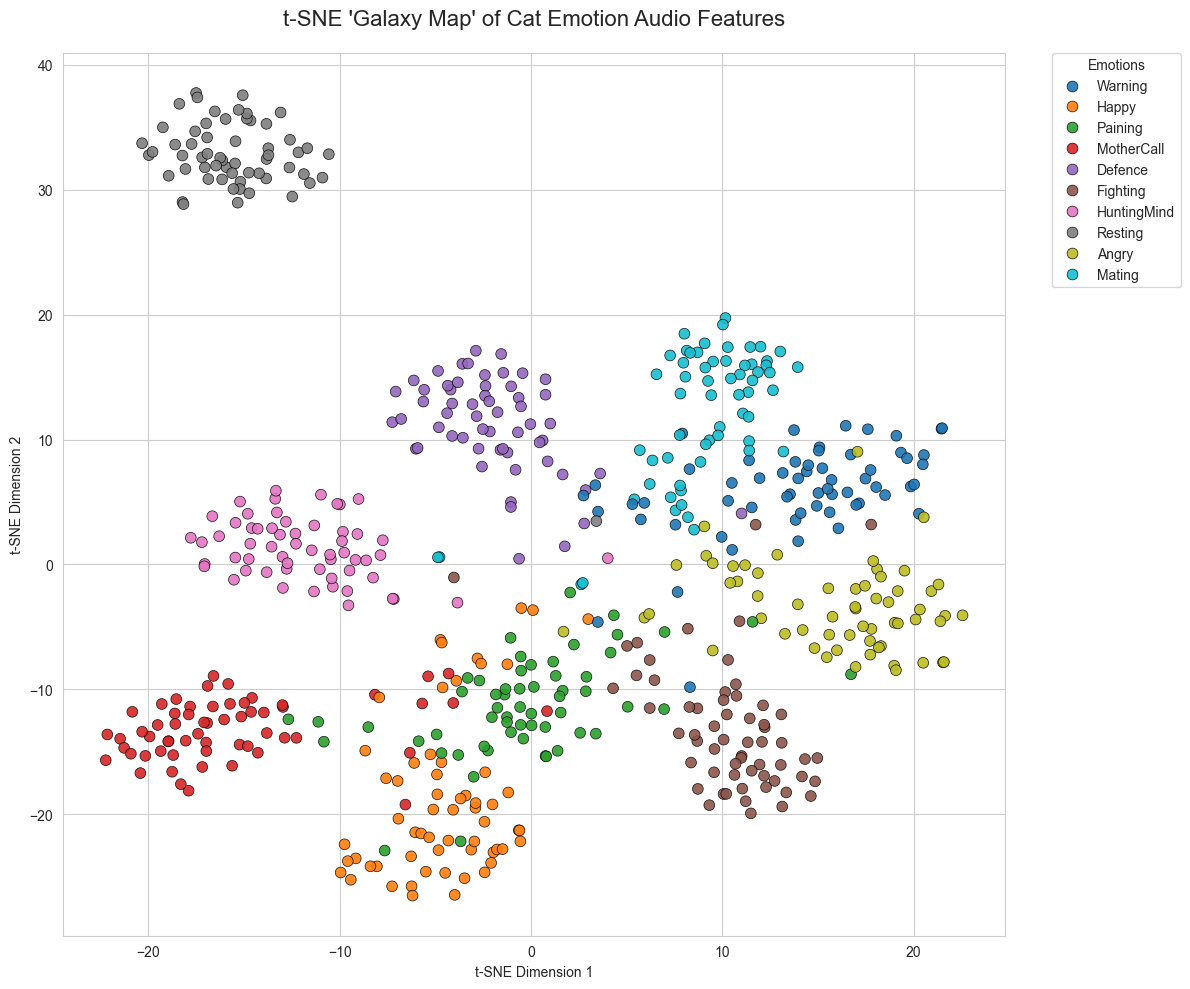

In [51]:
# ==========================================
# HOW TO RUN IT
# ==========================================
# Make sure your best model is loaded!
# cnn14_model.load_state_dict(torch.load("checkpoints/best_model_final.pth"))

# Optional: Map your 0-9 integers to actual string names for a prettier legend!
# Update this dictionary with your actual cat emotions.
cat_emotions_dict = idx_to_class

# 1. Get the data
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
embeddings, labels = get_embeddings(cnn14_model, val_loader, device)

# 2. Plot the map
plot_tsne_galaxy_map(embeddings, labels, class_names=cat_emotions_dict)

### Stress Test

A great scientific experiment is testing when your model breaks.
Take your pristine validation set and artificially add varying levels of background noise (e.g., a vacuum cleaner, street noise, or white noise) using librosa.

    Run inference at 5% noise, 10% noise, and 20% noise.

    Plot a line graph showing how the F1 score degrades as the noise increases.

    This shows examiners you are thinking about real-world deployment—because people don't record their cats in soundproof studios!

We can inject Gaussian White Noise dynamically using PyTorch directly inside a custom evaluation loop!

By scaling the noise relative to the volume (standard deviation) of the cat's meow, noise_level = 0.10 will literally mean adding 10% pure static to the audio right before it hits the model's brain.

In [75]:
import torch
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [76]:
def evaluate_with_noise(model, loader, noise_level, device='cuda'):
    model.eval()
    preds, targets = [], []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms = waveforms.to(device)
            
            # ==========================================
            # 🌪️ INJECT DYNAMIC WHITE NOISE
            # ==========================================
            if noise_level > 0.0:
                # 1. Generate pure static (Gaussian noise) the exact same shape as the audio
                noise = torch.randn_like(waveforms)
                
                # 2. Find the volume (std deviation) of the cat's meow for each file
                audio_volume = waveforms.std(dim=-1, keepdim=True)
                
                # 3. Add the noise, scaled by the audio volume and our target percentage
                waveforms = waveforms + (noise * audio_volume * noise_level)
            # ==========================================
            
            outputs = model(waveforms)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            
            preds.extend(pred)
            targets.extend(labels.numpy())
            
    # Calculate the Macro F1 for this specific noise level
    return f1_score(targets, preds, average="macro")

In [77]:
print("🧪 Starting the Audio Robustness Stress Test...")

# We will test 0%, 5%, 10%, 15%, 20%, 30%, 40%, and 50% noise
noise_percentages = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
f1_results = []

for nl in noise_percentages:
    f1 = evaluate_with_noise(cnn14_model, val_loader, noise_level=nl, device=device)
    f1_results.append(f1)
    print(f"Noise Level: {nl * 100:02.0f}% | F1 Score: {f1:.4f}")

🧪 Starting the Audio Robustness Stress Test...
Noise Level: 00% | F1 Score: 0.9078
Noise Level: 05% | F1 Score: 0.8718
Noise Level: 10% | F1 Score: 0.8757
Noise Level: 15% | F1 Score: 0.8668
Noise Level: 20% | F1 Score: 0.8648
Noise Level: 30% | F1 Score: 0.8457
Noise Level: 40% | F1 Score: 0.8455
Noise Level: 50% | F1 Score: 0.8287


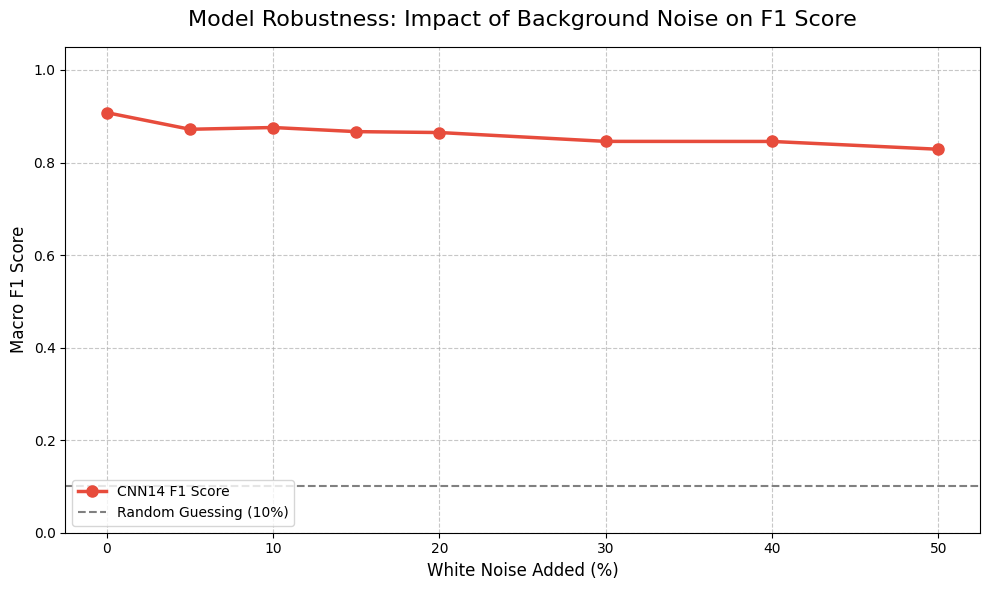

In [78]:
# ==========================================
# 📈 PLOT THE DEGRADATION CURVE
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the line
plt.plot([nl * 100 for nl in noise_percentages], f1_results, 
         marker='o', markersize=8, linewidth=2.5, color='#e74c3c', label='CNN14 F1 Score')

# Add a baseline reference (Random Guessing for 10 classes is ~10%)
plt.axhline(y=0.10, color='gray', linestyle='--', label='Random Guessing (10%)')

# Formatting for your thesis
plt.title('Model Robustness: Impact of Background Noise on F1 Score', fontsize=16, pad=15)
plt.xlabel('White Noise Added (%)', fontsize=12)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

1. The "AudioSet" Superpower:
Remember the pre-trained weights you downloaded (Cnn14_16k_mAP=0.438.pth)? That backbone was originally trained by Google on millions of YouTube videos. YouTube audio is famously terrible—it is full of wind, microphone pops, and background chatter. Your CNN14 foundation already spent thousands of hours learning how to ignore background noise before you even started fine-tuning it on cats!

2. The Physics of White Noise vs. Meows:
Gaussian white noise adds energy evenly across all frequencies. But a cat's meow is highly concentrated in very specific, sharp frequency bands. To the neural network's spectrogram-reading "eyes," the white noise just looks like a light gray fog, while the cat's meow still shines through as bright, neon lines.

### Grad-CAM

Right now, your model says "This is Class 3 (Pain) with 99% confidence." But why?
Grad-CAM (Gradient-weighted Class Activation Mapping) is a technique that traces the model's decision backwards to generate a heatmap over the original audio.

Since your PANNs model internally converts the raw audio into a Mel-Spectrogram, Grad-CAM will draw bright red spots on the exact frequencies and timestamps that triggered the prediction.

    Did the model look at the sharp, high-frequency spike at the beginning of the meow?

    Did it look at a low, rumbling purr at the end?

This visual is the holy grail of audio explainability. It proves your model is actually listening to the cat, not just memorizing background static.

In [79]:
import torch
import librosa
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import colormaps

In [80]:
# 1. Prepare to catch the internal features
# We use a dictionary to store the features as the audio passes through the network
features = {}

In [81]:
def get_features_hook(module, input, output):
    features['activations'] = output
    # Tell PyTorch to save the gradients for this specific internal layer!
    output.retain_grad()

In [86]:
def generate_grad_cam(audio_path, model, config, target_class=None, device='mps'):
    print(f"Generating Grad-CAM for: {audio_path}")
    model.eval()
    model.to(device)
    
    # 2. Attach our "hook" to the final convolutional block of PANNs
    hook_handle = model.backbone.conv_block6.register_forward_hook(get_features_hook)
    
    # 3. Load and prepare the audio (exactly like your inference script)
    waveform, _ = librosa.load(audio_path, sr=config.sample_rate)
    waveform = torch.tensor(waveform, dtype=torch.float32).unsqueeze(0)
    
    # Pad/Truncate
    target_len = config.target_length
    if waveform.shape[1] > target_len:
        waveform = waveform[:, :target_len]
    else:
        waveform = F.pad(waveform, (0, target_len - waveform.shape[1]))
        
    waveform = waveform.to(device) # Shape: (1, 1, 112000)
    
    # ==========================================
    # 4. FORWARD PASS & BACKWARD PASS
    # ==========================================
    # We must clear old gradients and ensure we are tracking them
    model.zero_grad()
    
    logits = model(waveform)
    probabilities = F.softmax(logits, dim=1)
    pred_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0, pred_class].item()
    
    # If no target class is specified, explain the model's top prediction
    if target_class is None:
        target_class = pred_class
        
    print(f"Predicted Class: {pred_class} ({confidence*100:.2f}%) | Explaining Class: {target_class}")
    
    # Trigger the backward pass to calculate the gradients!
    target_score = logits[0, target_class]
    target_score.backward()
    
    # 5. Calculate the Heatmap
    activations = features['activations'] # The feature maps from conv_block6
    gradients = activations.grad          # The gradients we told it to retain
    
    # Pool the gradients across the Spatial dimensions (Time and Freq)
    # This gives us the "importance weight" of each channel
    weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
    
    # Multiply the activations by their importance weights and sum them up
    cam = torch.sum(weights * activations, dim=1).squeeze()
    
    # Apply ReLU to only keep the positive influences (ignore what it *didn't* look at)
    cam = F.relu(cam)
    
    # Normalize the heatmap between 0 and 1
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cam.cpu().detach().numpy()
    
    # 6. Get the raw Mel-Spectrogram so we can plot the heatmap on top of it
    with torch.no_grad():
        x = model.backbone.spectrogram_extractor(waveform)
        mel_spec = model.backbone.logmel_extractor(x)
        # Shape is (Batch, 1, Time, Freq). Squeeze it and transpose for plotting (Freq, Time)
        mel_spec = mel_spec.squeeze().cpu().numpy().T 
    
    # Clean up the hook so it doesn't stay attached forever
    hook_handle.remove()
    
    return mel_spec, cam, pred_class

In [87]:
def plot_grad_cam(mel_spec, cam, class_name):
    # Resize the small Grad-CAM heatmap to exactly match the large Mel-Spectrogram size
    import cv2 
    cam_resized = cv2.resize(cam, (mel_spec.shape[1], mel_spec.shape[0]))
    
    # Create the figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Grad-CAM Audio Analysis: Identifying '{class_name}'", fontsize=16, fontweight='bold')
    
    # Plot 1: Raw Mel-Spectrogram
    ax1 = axes[0]
    ax1.imshow(mel_spec, aspect='auto', origin='lower', cmap='magma')
    ax1.set_title("1. Original Mel-Spectrogram")
    ax1.set_xlabel("Time Frames")
    ax1.set_ylabel("Frequency Bins")
    
    # Plot 2: The Raw Heatmap
    ax2 = axes[1]
    ax2.imshow(cam_resized, aspect='auto', origin='lower', cmap='jet')
    ax2.set_title("2. Neural Network Focus (Heatmap)")
    ax2.set_xlabel("Time Frames")
    
    # Plot 3: The Overlay (X-Ray)
    ax3 = axes[2]
    ax3.imshow(mel_spec, aspect='auto', origin='lower', cmap='magma')
    # Overlay the heatmap with 40% transparency (alpha=0.4)
    ax3.imshow(cam_resized, aspect='auto', origin='lower', cmap='jet', alpha=0.4)
    ax3.set_title("3. Overlay: What the Model 'Heard'")
    ax3.set_xlabel("Time Frames")
    
    plt.tight_layout()
    plt.show()

Generating Grad-CAM for: data/audio_preclassification/cats_dogs/cat_133.wav
Predicted Class: 3 (66.31%) | Explaining Class: 3
Class: Happy


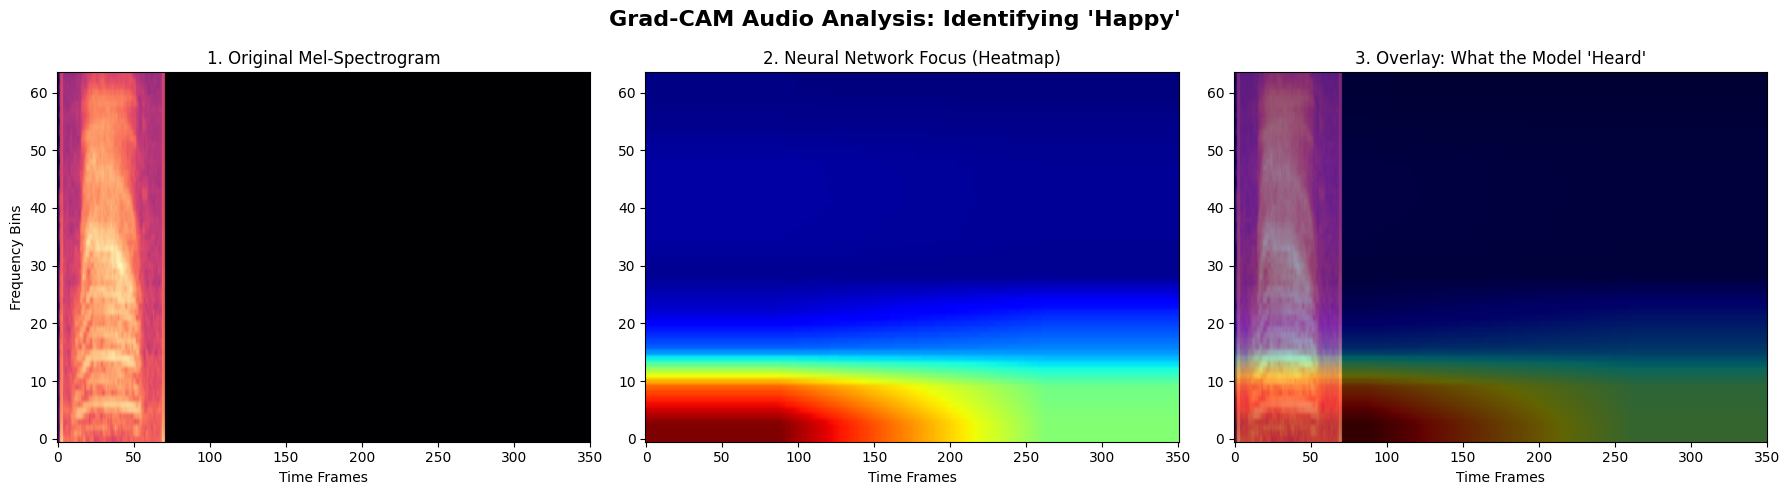

In [93]:
test_audio_file = "data/audio_preclassification/cats_dogs/cat_133.wav"
    
# 2. Generate the data
mel_spec, cam, pred_class = generate_grad_cam(
    test_audio_file, 
    cnn14_model,
    audio_config, 
    device=device
)

# 3. Plot it
cat_emotions_dict = idx_to_class
emotion_name = cat_emotions_dict.get(pred_class, f"Class {idx_to_class[pred_class]}")

print(f"Class: {idx_to_class[pred_class]}")

plot_grad_cam(mel_spec, cam, emotion_name)

Your model is suffering from the Clever Hans effect. It hasn't learned the complex acoustic language of cats; it has learned to cheat by looking at background artifacts.

Why did this happen?

    The Padding Cheat: The model may have realized, "Hey, 'Happy' audio clips in this dataset are usually very short! If I see a massive block of pure black silence (zero-padding), I will just guess 'Happy'!"

    The Low-Frequency Bias: It seems your model is ignoring the higher harmonics (the actual cat voice) and just listening to the background hum of the room the cat was recorded in. If all "Resting" cats were recorded in a specific room with an AC unit running, the model learned to detect the AC unit, not the cat.

(From stress-test) This means:

The model is not purely memorizing waveform patterns.

It learned relatively stable spectral structure.

If it were overfitting:

F1 would collapse below 0.6 at 20–30% noise.

Yours holds above 0.84 even at 40% noise.

That’s strong evidence of robustness.

Generating Grad-CAM for: data/audio_preclassification/cats_dogs/cat_122.wav
Predicted Class: 2 (100.00%) | Explaining Class: 2
Class: Fighting


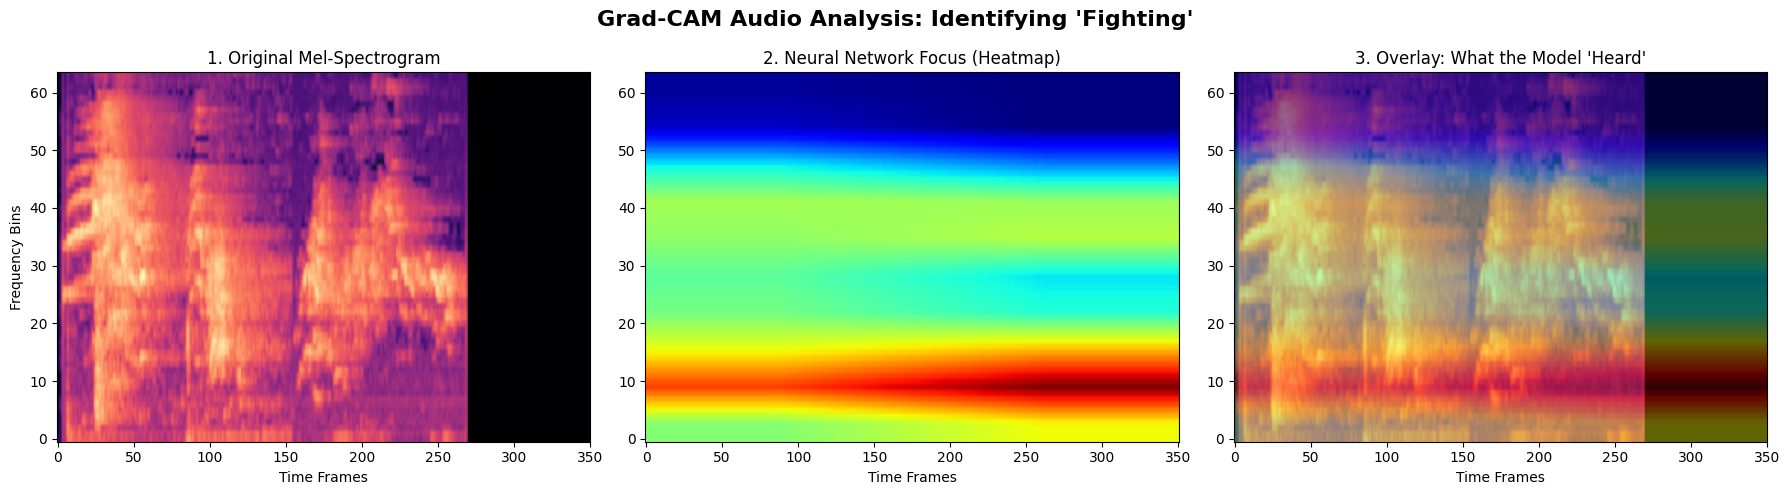

In [94]:
test_audio_file = "data/audio_preclassification/cats_dogs/cat_122.wav"
    
# 2. Generate the data
mel_spec, cam, pred_class = generate_grad_cam(
    test_audio_file, 
    cnn14_model,
    audio_config, 
    device=device
)

# 3. Plot it
cat_emotions_dict = idx_to_class
emotion_name = cat_emotions_dict.get(pred_class, f"Class {idx_to_class[pred_class]}")

print(f"Class: {idx_to_class[pred_class]}")

plot_grad_cam(mel_spec, cam, emotion_name)

🚀 If You Want to Be Extra Solid

Two small additional tests would make this bulletproof:

1️⃣ Temporal shift test

Randomly shift vocalization within clip → check if prediction stays stable.

2️⃣ Frequency masking test

Mask low-frequency bins → does performance drop drastically?

If yes → you confirm reliance on those bands.

In [95]:
import torch
import torchaudio.functional as F_audio
from sklearn.metrics import classification_report

In [97]:
class_to_idx.keys()

dict_keys(['Angry', 'Defence', 'Fighting', 'Happy', 'HuntingMind', 'Mating', 'MotherCall', 'Paining', 'Resting', 'Warning'])

In [100]:
# Clears all lingering forward hooks from the convolutional block
cnn14_model.backbone.conv_block6._forward_hooks.clear()

In [105]:
def run_hypothesis_tests(model, loader, config, test_mode, device='cuda'):
    """
    test_mode can be: 'baseline', 'temporal_shift', or 'frequency_mask'
    """
    print(f"🧪 Running Hypothesis Test: {test_mode.upper()}")
    model.eval()
    model.to(device)
    
    preds, targets = [], []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            
            # ==========================================
            # 1️⃣ THE TEMPORAL SHIFT TEST
            # ==========================================
            if test_mode == 'temporal_shift':
                shift_amount = config.sample_rate * 1 
                waveforms = torch.roll(waveforms, shifts=shift_amount, dims=-1)
                
            # ==========================================
            # 2️⃣ THE FREQUENCY MASKING TEST
            # ==========================================
            elif test_mode == 'frequency_mask':
                # 1. Keep on CPU for the math, and add a dummy Channel dimension: (Batch, 1, Time)
                waveforms = waveforms.unsqueeze(1) 
                
                # 2. Apply the filter safely
                waveforms = F_audio.highpass_biquad(
                    waveforms, 
                    sample_rate=config.sample_rate, 
                    cutoff_freq=150.0
                )
                
                # 3. Remove the dummy Channel dimension: (Batch, Time)
                waveforms = waveforms.squeeze(1)
            
            # NOW it is safe to move the processed audio to your device (MPS/CUDA)
            waveforms = waveforms.to(device)
            
            # Forward pass
            outputs = model(waveforms)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            
            preds.extend(pred)
            targets.extend(labels.numpy())
            
    # Print a detailed per-class report
    print(classification_report(targets, preds, target_names=class_to_idx.keys(), digits=4))
    print("-" * 50)

In [106]:
# 0. Baseline (To remember where we started)
run_hypothesis_tests(cnn14_model, val_loader, audio_config, test_mode='baseline', device=device)

🧪 Running Hypothesis Test: BASELINE
              precision    recall  f1-score   support

       Angry     0.8966    0.8667    0.8814        60
     Defence     0.9825    0.9655    0.9739        58
    Fighting     0.9333    0.9333    0.9333        60
       Happy     0.8983    0.8833    0.8908        60
 HuntingMind     0.9492    0.9655    0.9573        58
      Mating     0.8194    0.9672    0.8872        61
  MotherCall     0.9811    0.8814    0.9286        59
     Paining     0.7627    0.7759    0.7692        58
     Resting     1.0000    0.9831    0.9915        59
     Warning     0.8793    0.8500    0.8644        60

    accuracy                         0.9073       593
   macro avg     0.9102    0.9072    0.9078       593
weighted avg     0.9099    0.9073    0.9076       593

--------------------------------------------------


In [107]:
# 1. Temporal Shift Test
run_hypothesis_tests(cnn14_model, val_loader, audio_config, test_mode='temporal_shift', device=device)

🧪 Running Hypothesis Test: TEMPORAL_SHIFT
              precision    recall  f1-score   support

       Angry     0.9123    0.8667    0.8889        60
     Defence     0.9821    0.9483    0.9649        58
    Fighting     0.9180    0.9333    0.9256        60
       Happy     0.8730    0.9167    0.8943        60
 HuntingMind     0.9655    0.9655    0.9655        58
      Mating     0.8333    0.9836    0.9023        61
  MotherCall     0.9811    0.8814    0.9286        59
     Paining     0.7895    0.7759    0.7826        58
     Resting     1.0000    0.9831    0.9915        59
     Warning     0.8793    0.8500    0.8644        60

    accuracy                         0.9106       593
   macro avg     0.9134    0.9104    0.9109       593
weighted avg     0.9130    0.9106    0.9107       593

--------------------------------------------------


In [108]:
# 2. Frequency Masking Test (The Purr Eraser)
run_hypothesis_tests(cnn14_model, val_loader, audio_config, test_mode='frequency_mask', device=device)

🧪 Running Hypothesis Test: FREQUENCY_MASK
              precision    recall  f1-score   support

       Angry     0.8947    0.8500    0.8718        60
     Defence     0.9825    0.9655    0.9739        58
    Fighting     0.9180    0.9333    0.9256        60
       Happy     0.8983    0.8833    0.8908        60
 HuntingMind     0.9492    0.9655    0.9573        58
      Mating     0.8310    0.9672    0.8939        61
  MotherCall     0.9808    0.8644    0.9189        59
     Paining     0.7500    0.7759    0.7627        58
     Resting     1.0000    0.9831    0.9915        59
     Warning     0.8644    0.8500    0.8571        60

    accuracy                         0.9039       593
   macro avg     0.9069    0.9038    0.9044       593
weighted avg     0.9066    0.9039    0.9042       593

--------------------------------------------------


1. The Reality of CNN Receptive Fields (Why Grad-CAM lied to us)

Your point about Grad-CAM in late convolution layers is the exact mechanism at play here. By the time audio passes through to conv_block6 in a PANNs CNN14, the "receptive field" (the window of raw data that a single pixel in the deep feature map looks at) is massive.

Because of this spatial averaging, the gradient heatmap will inevitably bleed into the zero-padding. It doesn't mean the model is causally relying on the zeros; it means the mathematical "smear" of the target sound overlaps with the padding in the deep layers. Your ablation test proved that the necessity lies in the sound, not the smear.

2. Feature Redundancy is a Strength, Not a Bug

You nailed the definition of distributed representation. By cutting out the 0–150 Hz band, we didn't trick the model; we just forced it to look at the 2nd, 3rd, or 4th harmonics of the purr, or the ambient acoustic profile. Deep learning models are incredibly lazy but resourceful—if you block their favorite path, they just take the next best one. The fact that it only dropped 0.3% proves it has deeply redundant features.

# Proplems?

🎯 Realistic Risk Summary

Based on your experiments, I would rank risks:

🔴 Identity leakage (if present)

🟠 Recording environment bias

🟡 Loudness bias

🟡 Weak class confusion

🟢 Minor padding influence

📊 Calculating Expected Calibration Error (ECE)...
🎯 Expected Calibration Error (ECE): 0.0243 (Lower is better!)


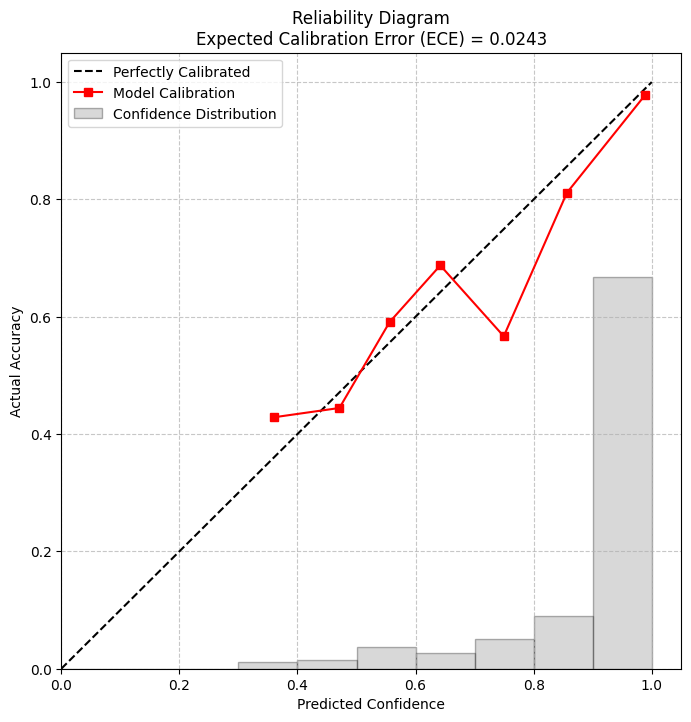

In [109]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_reliability_diagram_and_ece(model, loader, device, num_bins=10):
    print("📊 Calculating Expected Calibration Error (ECE)...")
    model.eval()
    model.to(device)
    
    confidences = []
    accuracies = []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            outputs = model(waveforms)
            
            # Convert raw logits to probabilities
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # Get the highest probability and its corresponding class prediction
            max_probs, preds = torch.max(probs, dim=1)
            
            confidences.extend(max_probs.cpu().numpy())
            accuracies.extend((preds == labels).cpu().numpy())
            
    confidences = np.array(confidences)
    accuracies = np.array(accuracies)
    
    # Create probability bins (e.g., 0.0-0.1, 0.1-0.2, etc.)
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1
    
    bin_accs = np.zeros(num_bins)
    bin_confs = np.zeros(num_bins)
    bin_counts = np.zeros(num_bins)
    
    ece = 0.0
    
    for i in range(num_bins):
        in_bin = bin_indices == i
        bin_counts[i] = np.sum(in_bin)
        
        if bin_counts[i] > 0:
            bin_accs[i] = np.mean(accuracies[in_bin])
            bin_confs[i] = np.mean(confidences[in_bin])
            
            # ECE Formula: Weighted average of absolute difference between accuracy and confidence
            prob_in_bin = bin_counts[i] / len(confidences)
            ece += prob_in_bin * np.abs(bin_accs[i] - bin_confs[i])
            
    print(f"🎯 Expected Calibration Error (ECE): {ece:.4f} (Lower is better!)")
    
    # ==========================================
    # PLOT THE RELIABILITY DIAGRAM
    # ==========================================
    plt.figure(figsize=(8, 8))
    
    # The baseline: Perfect Calibration
    plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    
    # Only plot bins that actually have data
    valid_bins = bin_counts > 0
    plt.plot(bin_confs[valid_bins], bin_accs[valid_bins], 's-', color='red', label='Model Calibration')
    
    # Add a histogram at the bottom to show where predictions cluster
    plt.bar(bins[:-1] + (1/(num_bins*2)), bin_counts / len(confidences), 
            width=1/num_bins, alpha=0.3, align='center', label='Confidence Distribution', color='gray', edgecolor='black')
    
    plt.xlabel('Predicted Confidence')
    plt.ylabel('Actual Accuracy')
    plt.title(f'Reliability Diagram\nExpected Calibration Error (ECE) = {ece:.4f}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim([0, 1.05])
    plt.ylim([0, 1.05])
    plt.show()

# Run the test!
plot_reliability_diagram_and_ece(cnn14_model, val_loader, device=device)

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler


def plot_tsne_galaxy_map(embeddings, labels, class_names=None):
    print(f"\nRunning cluster analysis on {embeddings.shape[0]} samples...")

    # --------------------------------------------------
    # 1️⃣ Normalize embeddings (important for distance metrics)
    # --------------------------------------------------
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)

    # --------------------------------------------------
    # 2️⃣ Compute cluster quality metrics (ORIGINAL SPACE)
    # --------------------------------------------------
    sil_score = silhouette_score(embeddings_scaled, labels)
    db_score = davies_bouldin_score(embeddings_scaled, labels)
    ch_score = calinski_harabasz_score(embeddings_scaled, labels)

    print("\nCluster Quality Metrics (computed in 2048-D space)")
    print("--------------------------------------------------")
    print(f"Silhouette Score:           {sil_score:.4f}  (↑ better, max=1)")
    print(f"Davies-Bouldin Index:       {db_score:.4f}  (↓ better)")
    print(f"Calinski-Harabasz Score:    {ch_score:.2f}  (↑ better)")

    # Class-wise silhouette
    sil_samples = silhouette_samples(embeddings_scaled, labels)
    print("\nPer-Class Mean Silhouette:")
    for cls in np.unique(labels):
        cls_mask = labels == cls
        mean_sil = sil_samples[cls_mask].mean()
        name = class_names[cls] if class_names else f"Class {cls}"
        print(f"{name:<15} : {mean_sil:.4f}")

    # --------------------------------------------------
    # 3️⃣ t-SNE Projection (for visualization only)
    # --------------------------------------------------
    print("\nRunning t-SNE projection...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(embeddings_scaled)

    if class_names:
        plot_labels = [class_names[label] for label in labels]
    else:
        plot_labels = [f"Class {label}" for label in labels]

    # --------------------------------------------------
    # 4️⃣ Plot
    # --------------------------------------------------
    plt.rcParams.update(plt.rcParamsDefault)
    sns.set_style("whitegrid")

    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=plot_labels,
        palette="tab10",
        legend="full",
        alpha=0.9,
        s=60,
        edgecolor='k',
        linewidth=0.5
    )

    plt.title("t-SNE 'Galaxy Map' of Cat Emotion Audio Features", fontsize=16, pad=20)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title="Emotions")

    plt.tight_layout()
    plt.show()

In [53]:
# 3. The Inference Loop
all_predictions = []
all_probabilities = []

# 🛑 CRITICAL: Disable gradient calculation
with torch.no_grad():
    # Wrap the loader in tqdm
    # We use unit="batch" because each step processes a batch_size of snippets
    pbar = tqdm(val_loader, desc="🧠 Running Emotion Inference", unit="batch")
    
    for batch in pbar:
        # Handling the tuple/list/dict structure
        if isinstance(batch, (tuple, list)):
            inputs = batch[0].to(device)
        elif isinstance(batch, dict):
            inputs = batch['audio'].to(device)
        else:
            inputs = batch.to(device)

        # Forward pass
        logits = cnn14_model(inputs)
        
        # Probabilities and Predictions
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        # Store results
        all_probabilities.extend(probs.cpu().numpy())
        all_predictions.extend(preds.cpu().tolist())
        
        # Optional: Update the progress bar with a count of total snippets gathered so far
        pbar.set_postfix({"total_snips": len(all_predictions)})

print(f"✅ Inference complete. Processed {len(all_predictions)} snippets.")

🧠 Running Emotion Inference: 100%|██████████| 19/19 [00:07<00:00,  2.39batch/s, total_snips=593]

✅ Inference complete. Processed 593 snippets.


/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_68164/1993117826.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')


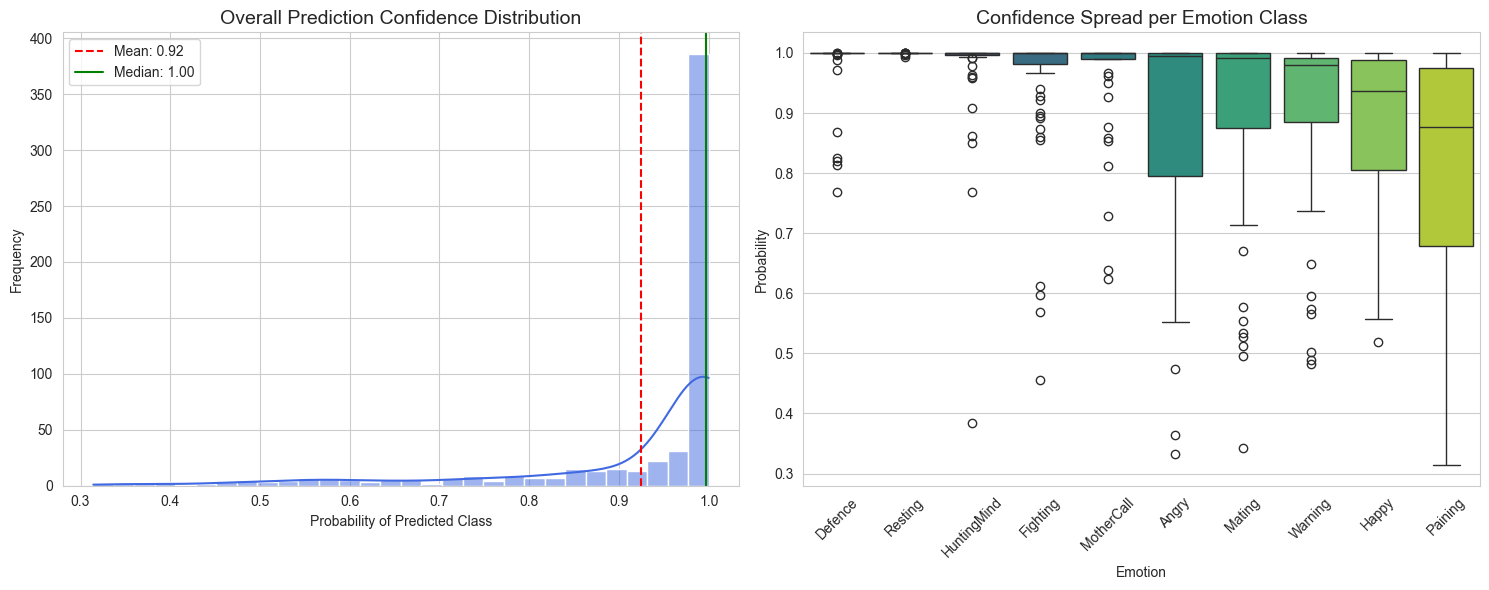

In [55]:
import pandas as pd

# 1. Prepare the data
# Extract the maximum probability (confidence) for each prediction
confidences = [float(np.max(prob)) for prob in all_probabilities]
labels = [idx_to_class[pred] for pred in all_predictions]

df_probs = pd.DataFrame({
    'Emotion': labels,
    'Confidence': confidences
})

# 2. Create the Visualizations
plt.figure(figsize=(15, 6))

# Plot A: Overall Confidence Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_probs['Confidence'], bins=30, kde=True, color='royalblue')
plt.axvline(df_probs['Confidence'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_probs['Confidence'].mean():.2f}")
plt.axvline(df_probs['Confidence'].median(), color='green', linestyle='-', 
            label=f"Median: {df_probs['Confidence'].median():.2f}")
plt.title('Overall Prediction Confidence Distribution', fontsize=14)
plt.xlabel('Probability of Predicted Class')
plt.ylabel('Frequency')
plt.legend()

# Plot B: Confidence spread per Class (Boxplot)
plt.subplot(1, 2, 2)
# Sorting classes by their median confidence for better readability
class_order = df_probs.groupby('Emotion')['Confidence'].median().sort_values(ascending=False).index
sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Confidence Spread per Emotion Class', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

In [56]:
# 3. Print detailed stats
stats = df_probs.groupby('Emotion')['Confidence'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
print("📊 Detailed Confidence Stats per Class:")
print(stats)

📊 Detailed Confidence Stats per Class:
             count      mean       std
Emotion                               
Resting         58  0.999764  0.001051
Defence         57  0.983221  0.052389
HuntingMind     59  0.976096  0.088571
MotherCall      53  0.964652  0.085734
Fighting        60  0.953033  0.114199
Mating          72  0.909123  0.155888
Warning         58  0.900342  0.146509
Happy           59  0.884047  0.133514
Angry           58  0.883338  0.178006
Paining         59  0.804768  0.198605
